# **1. Perkenalan Dataset**


Dataset yang saya gunakan adalah Medical Cost Personal Datasets yang saya dapatkan dari laman Kaggle.

Dataset ini berisi data mengenai biaya asuransi kesehatan yang
dibayarkan oleh perusahaan asuransi kepada para nasabah.

Setiap baris dalam
dataset merepresentasikan seorang individu dengan beberapa atribut seperti:

*   usia (age)
*   jenis kelamin (sex)
*   indeks massa tubuh (BMI)
*   jumlah anak yang ditanggung (smoker)
*   status perokok (smoker)
*   wilayah tempat tinggal (region)
*   total biaya asuransi (charges).





Tujuan utama dari penggunaan dataset ini adalah untuk menganalisis faktor
faktor yang memengaruhi besarnya biaya asuransi serta memprediksi nilai charges
berdasarkan karakteristik individu tersebut.

Link dataset: https://www.kaggle.com/datasets/mirichoi0218/insurance


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [20]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [22]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.0000,27.00000,39.000,51.000000,64.00000
bmi,1338.0,30.663397,6.098187,15.9600,26.29625,30.400,34.693750,53.13000
children,1338.0,1.094918,1.205493,0.0000,0.00000,1.000,2.000000,5.00000
charges,1338.0,13270.422265,12110.011237,1121.8739,4740.28715,9382.033,16639.912515,63770.42801


In [23]:
print("📊 Modus tiap Kolom:")
modus_series = df.apply(lambda x: x.mode()[0])
print(modus_series.to_frame(name='Modus'))

📊 Modus tiap Kolom:
              Modus
age              18
sex            male
bmi            32.3
children          0
smoker           no
region    southeast
charges   1639.5631


In [24]:
print("📊 Median tiap kolom numerik:")
print(df.median(numeric_only=True))

📊 Median tiap kolom numerik:
age           39.000
bmi           30.400
children       1.000
charges     9382.033
dtype: float64


In [25]:
df.dtypes

,0
age,int64
sex,object
bmi,float64
children,int64
smoker,object
region,object
charges,float64


In [26]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

/tmp/ipython-input-1230435631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=column, palette='Set3')


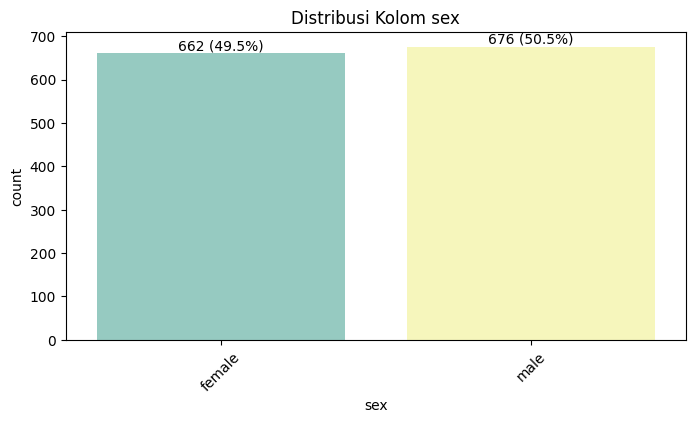

/tmp/ipython-input-1230435631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=column, palette='Set3')


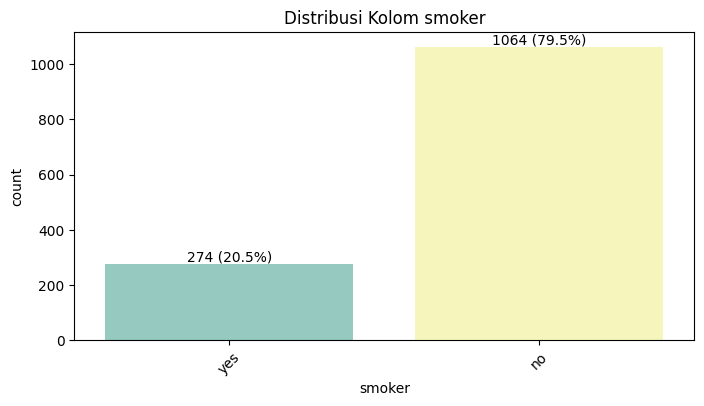

/tmp/ipython-input-1230435631.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=column, palette='Set3')


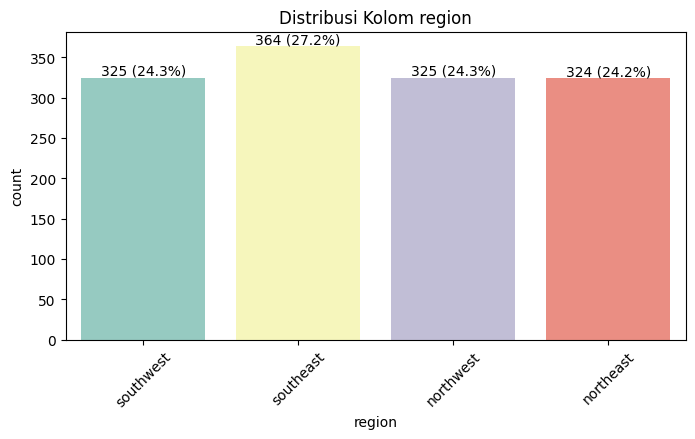

In [27]:
#Distribusi kolom kategorikal
for column in categorical_columns:
    plt.figure(figsize=(8, 4))
    ax = sns.countplot(data=df, x=column, palette='Set3')
    plt.title(f'Distribusi Kolom {column}')
    plt.xticks(rotation=45)

    total = len(df[column])

    for container in ax.containers:
        ax.bar_label(container, labels=[
            f'{int(v.get_height())} ({v.get_height()/total:.1%})' for v in container
        ])

    plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [28]:
# Duplikat DataFrame untuk Preprocessing
dataset = df.copy()

In [29]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [30]:
#Cek missing value
print("Missing values tiap kolom:")
dataset.isnull().sum()

Missing values tiap kolom:


,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [31]:
# Deteksi outlier (pakai IQR di kolom charges)
Q1 = dataset['charges'].quantile(0.25)
Q3 = dataset['charges'].quantile(0.75)
IQR = Q3 - Q1
outliers = dataset[(dataset['charges'] < Q1 - 1.5*IQR) | (dataset['charges'] > Q3 + 1.5*IQR)]
print("Jumlah outlier pada charges:", len(outliers))

Jumlah outlier pada charges: 139


In [32]:
#Encoding kolom kategorikal
le = LabelEncoder()
for col in ['sex', 'smoker']:
    dataset[col] = le.fit_transform(dataset[col])

In [33]:
dataset = pd.get_dummies(dataset, columns=['region'])

In [34]:
#Normalisasi/Standarisasi Kolom Numerik
scaler = StandardScaler()
num_cols = ['age','bmi','children']
dataset[num_cols] = scaler.fit_transform(dataset[num_cols])

In [35]:
print("Data setelah transformasi:")
dataset.head()

Data setelah transformasi:


,age,sex,bmi,children,smoker,charges,region_northeast,region_northwest,region_southeast,region_southwest
0,-1.438764,0,-0.453320,-0.908614,1,16884.92400,False,False,False,True
1,-1.509965,1,0.509621,-0.078767,0,1725.55230,False,False,True,False
2,-0.797954,1,0.383307,1.580926,0,4449.46200,False,False,True,False
3,-0.441948,1,-1.305531,-0.908614,0,21984.47061,False,True,False,False
4,-0.513149,1,-0.292556,-0.908614,0,3866.85520,False,True,False,False


In [36]:
# Menyimpan dataset yang sudah bersih ke dalam satu file CSV
dataset.to_csv('insurance_preprocessing.csv', index=False)

print("File insurance_preprocessing.csv berhasil dibuat!")

File insurance_preprocessing.csv berhasil dibuat!
